# Mo Notebook
# Intro to Jupyter and Exploratory Data Analysis (EDA)

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

REQ: For EDA projects, include dataset, description, and source information.

- Author: [Mahammad Hajiyev](https://github.com/denisecase/)
- Repository: [datafun-04-notebooks](https://github.com/MahammadHajiyev2024/datafun-04-notebooks)
- Purpose: Demonstrate a repeatable EDA workflow for a new, unexplored dataset
- Date: 2026-06-02

## Instructions

- Scan the headings first, to get an idea of the process and overall goal. 
- The provided content is a well-structured example that shows the process.
- Seek to understand the process and presentation of the work. 
- The goal is to be able to perform EDA **on any data you choose**. 

## Dataset Information

- Dataset: NFL statistics and FIFA Players
- Description: Size measurements for NFL and FIFA Players
- Source: https://www.kaggle.com/datasets/kendallgillies/nflstatistics?resource=download , https://www.kaggle.com/datasets/maso0dahmed/football-players-data
- Access: Available at Kaggle 

This is a Markdown cell.

## Section 0a. Intro to Jupyter Notebooks

This is a Markdown cell (not a Python cell). 
Here are a few tips to help you get started with Jupyter Notebooks:

- To run a cell, press **Ctrl+Enter** (or **Cmd+Enter** on Mac) when you're done editing the cell.
- You can change the type of a cell (e.g., code or markdown) by looking in the lower left corner of the notebook interface.
- You can rearrange cells by dragging and dropping them within the notebook.
- After creating a new notebook, use **File > Save as** to rename and save it into your project repository `notebooks` folder.
- To select a kernel (Python environment) for your notebook in Visual Studio Code, click on the **Select Kernel** name in the top-right corner of the notebook interface and choose the desired kernel from the dropdown menu. 
- Follow suggestions to install recommended extensions. 
- Once installed, click Select Kernel / Python Environments and choose the Recommended `.venv` option created earlier. 
- This will create a new kernel for the notebook and allow the notebook to use packages installed in the .venv/ environment.

Once skilled with Notebooks, you can delete this entire cell or create custom notes.

This is a Markdown cell.  


## Section 0b. Intro to EDA

### WHEN to do EDA

Perform Exploratory Data Analysis (EDA) when encountering a new data source, even if:

- You did not collect the data
- Someone else already analyzed it
- It comes from a trusted system

EDA helps to understand:

- What data is actually available
- What is missing, duplicated, or inconsistent
- What questions the data can and cannot answer

### GOALS of EDA

EDA is not the final report. EDA is about:

- Understanding structure and scale
- Detecting issues early
- Identifying next steps (cleaning, modeling, collection)

This notebook shows a standard EDA workflow that works for most **tabular** datasets.

Once you understand EDA, you can delete this entire cell or create custom notes.

This is a Markdown cell.

## Section 1. Project Setup and Imports

All imports and configuration appear once, at the top of the notebook.

WHY:
- Keeps notebooks readable and reproducible
- Mirrors professional scripts
- Makes it clear what must be installed

This is a Markdown cell.

In [53]:
# This is a Python cell.
# === Section 1c. Global Constants and Configuration ===
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import logging as LOG


DATASET_NAME = "Soccer_Vs_Football_Players_BMI.csv"
GROUP_COL = "Sport"

# Register our numerical tracking variables
SELECTED_NUMERIC_COLS = ["Height (cm) ", "Weight (kgs)", "bmi"]

# Set display rules for output readability
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

## Section 2. Load the Data

This is a Markdown cell.

WHY: Before analysis, load the data to confirm:

- The dataset loads successfully
- The structure matches expectations
- Column names are available and readable

This is a Markdown cell.

In [54]:
# Python cell

# Load a dataset into a DataFrame.

# Seaborn provides clean built-in datasets for practice.
# Other projects may load from CSV, JSON, or a database.

# Load the penguins dataset from Seaborn
# Into a pandas DataFrame (2D table)
LOG.info(f"Loading dataset: {DATASET_NAME}")
csv_path = f"../data/raw/{DATASET_NAME}"
LOG.info(f"Ingesting custom analytics dataset from: {csv_path}")
df = pd.read_csv(csv_path)

## Section 3. Inspect Data Shape and Structure

WHY: Always start by understanding what columns exist,
what types they are, and how large the dataset is.

- How many rows and columns are there?
- What types of data are present?
- Are there obvious missing values?

This step determines challenges we might have downstream (later).

This is a Markdown cell.

In [55]:
# Section 3 Python cell

# Preview the first few rows
# WHY: display() renders the DataFrame as a formatted table in the notebook.
#      A naked expression like df.head() only renders if it is the LAST line in a cell.
LOG.info("Previewing first few rows of the dataset")
display(df.head())

,Sport,Name,Age,Height (inches),Height (cm),Weight (lbs),Weight (kgs),Unnamed: 7,Unnamed: 8
0,Soccer,L. Messi,31.0,67,170.18,159,72.1,NaN,NaN
1,Soccer,C. Eriksen,27.0,61,154.94,168,76.2,NaN,NaN
2,Soccer,P. Pogba,25.0,75,190.50,185,83.9,NaN,NaN
3,Soccer,L. Insigne,27.0,64,162.56,130,59.0,NaN,NaN
4,Soccer,K. Koulibaly,27.0,74,187.96,196,88.9,NaN,NaN


In [56]:
# Section 3 Python cell

LOG.info("Column names")
print(list(df.columns))

['Sport', 'Name', 'Age', 'Height (inches)', 'Height (cm) ', 'Weight (lbs)', 'Weight (kgs)', 'Unnamed: 7', 'Unnamed: 8']


In [57]:
# Section 3 Python cell

# DataFrame info (types and non-null counts)
# WHY: df.info() prints directly - no display() needed.
LOG.info("DataFrame info (types and non-null counts)")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sport            998 non-null    str    
 1   Name             998 non-null    str    
 2   Age              969 non-null    float64
 3   Height (inches)  998 non-null    int64  
 4   Height (cm)      998 non-null    float64
 5   Weight (lbs)     998 non-null    int64  
 6   Weight (kgs)     998 non-null    float64
 7   Unnamed: 7       0 non-null      float64
 8   Unnamed: 8       1 non-null      str    
dtypes: float64(4), int64(2), str(3)
memory usage: 70.3 KB


In [58]:
# Section 3 Python cell

# Get shape - number of rows and columns
# It has two parts so the return value is a tuple of (num_rows, num_columns)
shape: tuple[int, int] = df.shape

# To get each value, we can unpack the tuple into two variables
# This is a common Python idiom for working with tuples.
# Or we could just use shape[0] and shape[1] directly without unpacking.

num_rows, num_cols = shape

LOG.info(f"Dataset shape: {num_rows} rows, {num_cols} columns")

## Section 4. Create Data Dictionary and Check Data Quality

WHY: A data dictionary helps with understanding the structure and quality of the data.

WHY: Missing data is normal. We need to find out how much and where.

Missing data affects:

- Visualizations
- Summary statistics
- Machine learning models

LOOK FOR: 

- Columns with many missing values
- Patterns (entire rows missing multiple fields)

This is a Markdown cell.


In [59]:
# Section 4 Python cell

LOG.info("Building starter data dictionary")

data_dictionary = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": [str(t) for t in df.dtypes],
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
    }
)

LOG.debug(f"\n{data_dictionary}")

In [60]:
# Section 4 Python cell

# === Section 4. Initial Quality Control Checks ===
print("Missing values detected per column:")
print(df.isnull().sum())

print("\nDuplicate row count:", df.duplicated().sum())

print("\nDescriptive statistics for raw dimensions:")
raw_cols = ["Height (cm) ", "Weight (kgs)"]
display(df[raw_cols].describe().T)

Missing values detected per column:
Sport                0
Name                 0
Age                 29
Height (inches)      0
Height (cm)          0
Weight (lbs)         0
Weight (kgs)         0
Unnamed: 7         998
Unnamed: 8         997
dtype: int64

Duplicate row count: 0

Descriptive statistics for raw dimensions:


,count,mean,std,min,25%,50%,75%,max
Height (cm),998.0,182.419339,12.208255,152.4,175.26,185.42,190.5,205.74
Weight (kgs),998.0,94.516032,23.855472,55.8,76.20,87.10,104.8,165.10


## Section 5. Create Clean View for EDA

Create a cleaned view for EDA.

Strategy:
  - Keep the original DataFrame unchanged
  - Drop rows missing key numeric fields and grouping field

WHY: EDA often focuses on a "clean" subset of the data.

This allows exploring patterns without being distracted by missing values.

This is a Markdown cell.

In [61]:
# === Section 5.

# === Section 5. Create Clean View and Engineer BMI Feature ===

GROUP_COL = "Sport"
height_col = "Height (cm) "  # Keeping that trailing space
weight_col = "Weight (kgs)"

# 1. Define raw tracking columns based on your exact CSV names
cols_required = ["Height (cm) ", "Weight (kgs)", GROUP_COL]

df_clean = df.dropna(subset=cols_required).copy()
# 2. Advanced Feature Engineering Calculation
# Formula: Weight (kgs) / (Height (cm) converted to meters squared)
df_clean["bmi"] = df_clean["Weight (kgs)"] / ((df_clean["Height (cm) "] / 100) ** 2)

print("Custom Feature Engineering Step Successful!")
print("Columns present in workspace:", list(df_clean.columns))
display(df_clean.head())

Custom Feature Engineering Step Successful!
Columns present in workspace: ['Sport', 'Name', 'Age', 'Height (inches)', 'Height (cm) ', 'Weight (lbs)', 'Weight (kgs)', 'Unnamed: 7', 'Unnamed: 8', 'bmi']


,Sport,Name,Age,Height (inches),Height (cm),Weight (lbs),Weight (kgs),Unnamed: 7,Unnamed: 8,bmi
0,Soccer,L. Messi,31.0,67,170.18,159,72.1,NaN,NaN,24.895349
1,Soccer,C. Eriksen,27.0,61,154.94,168,76.2,NaN,NaN,31.741531
2,Soccer,P. Pogba,25.0,75,190.50,185,83.9,NaN,NaN,23.119157
3,Soccer,L. Insigne,27.0,64,162.56,130,59.0,NaN,NaN,22.326705
4,Soccer,K. Koulibaly,27.0,74,187.96,196,88.9,NaN,NaN,25.163491


## Section 6. Descriptive Statistics for Numeric Columns

WHY: Summary statistics offer a quick overview of numeric data:

- Central tendency (mean)
- Spread (std, min, max)
- Distribution shape (quartiles)

Grouping by a categorical variable (i.e., non-numeric column)
enables comparing statistics across categories

This is a Markdown cell.

--- Grouped Dimension Averages by Sport ---


,Height (cm),Weight (kgs),bmi
Sport,,,
Football,188.290862,111.855511,31.351739
Soccer,176.547816,77.176553,25.037359



--- Computing Numeric Correlation Matrix ---


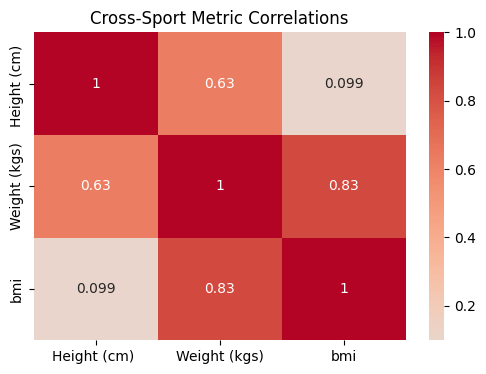

In [62]:
# === Section 6 & 7. Descriptive Statistics and Correlations ===
print(f"--- Grouped Dimension Averages by {GROUP_COL} ---")
grouped_summary = df_clean[SELECTED_NUMERIC_COLS].groupby(df_clean[GROUP_COL], observed=False).mean()
display(grouped_summary)

print("\n--- Computing Numeric Correlation Matrix ---")
corr = df_clean[SELECTED_NUMERIC_COLS].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Cross-Sport Metric Correlations")
plt.show()

In [63]:
# Section 6 Python cell

# LOG.info("--------------- Using pandas describe() method ---------------")

LOG.info("Computing overall descriptive statistics")

# Use describe() to get count, mean, std, min, 25%, 50%, 75%, max for numeric columns
# OPTION: Use .T to transpose the result so that columns become rows for easier reading in logs
stats_overall = df_clean[SELECTED_NUMERIC_COLS].describe().T
LOG.debug(f"\n{stats_overall}")

LOG.info("--------------- Using pandas groupby() and agg() ---------------")

LOG.info("Computing descriptive statistics by group")

# Step 1: Select only the numeric columns we want to summarize
df_numeric_subset: pd.DataFrame = df_clean[SELECTED_NUMERIC_COLS]

# Step 2: Split the numeric subset into groups based on the grouping column
# groupby() returns a GroupBy object - not a DataFrame yet, just a plan to group
grouped = df_numeric_subset.groupby(df_clean[GROUP_COL])

# Step 3: For each group, compute multiple summary statistics at once
# agg() applies each function in the list to each numeric column
# The result has a multi-level column index: (numeric_column, statistic)
df_stats_by_group: pd.DataFrame = grouped.agg(["count", "mean", "std", "min", "max"])

LOG.debug(f"\n{df_stats_by_group}")

In [64]:
# Section 6 Python cell

LOG.info("--------------- Improving the output ---------------")

# Yuck: That's the multi-level column index in action.
# pandas lays out the result as (numeric_column, statistic) pairs
# side by side, wrapping when the terminal width runs out.
# With 4 numeric columns x 5 statistics = 20 columns total,
# it can only fit 2 numeric columns per line at 120 characters wide.
# Let's stack it so each numeric column's stats are grouped together
# vertically instead of horizontally.

stats_by_group_stacked: pd.DataFrame | pd.Series[Any] = df_stats_by_group.stack(level=0)
LOG.debug(f"\n{stats_by_group_stacked}")

## Section 8. Make Plots

Create simple, notebook-friendly plots.

WHY: Visualizations reveal patterns not obvious in tables.
CUSTOM: Charts will vary depending on the dataset
        and questions of interest.

Common charts include:
1. A scatter plot to see relationships between two variables
2. A box plot to compare distributions across groups

A scatter plot shows the relationship between two numeric variables.
In this example:
- Each dot is one data record shown as x vs y.
- Color (hue) provides a third dimension.

A box plot shows the distribution of one numeric variable across groups.
- The box shows the middle 50% of values.
- The line inside the box is the median.
- The whiskers show the range. Dots beyond the whiskers are outliers.


This is a Markdown cell.

C:\Users\mhajiyev\AppData\Local\Temp\ipykernel_26116\2760934790.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x=GROUP_COL, y="bmi", palette="Set1")


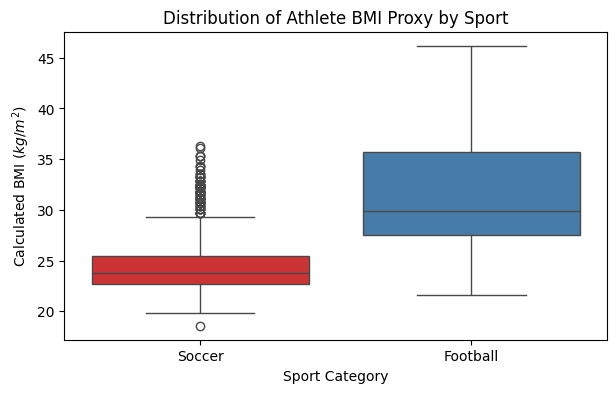

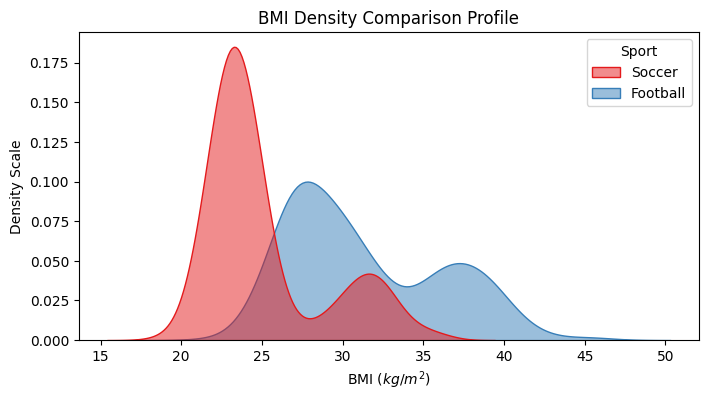

In [65]:
# === Section 8. Visualizations ===

# Plot 1: Box Plot showing the median spreads and range variations
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_clean, x=GROUP_COL, y="bmi", palette="Set1")
plt.title("Distribution of Athlete BMI Proxy by Sport")
plt.ylabel("Calculated BMI ($kg/m^2$)")
plt.xlabel("Sport Category")
plt.show()

# Plot 2: Density Profile Overlay (Shows the bi-modal spikes vs uniform clustering)
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df_clean, x="bmi", hue=GROUP_COL, fill=True, common_norm=False, palette="Set1", alpha=0.5)
plt.title("BMI Density Comparison Profile")
plt.xlabel("BMI ($kg/m^2$)")
plt.ylabel("Density Scale")
plt.show()

## Reminder: Run All before sending to GitHub

Before saving a notebook (and running git add-commit-push), click 'Run All' to generate all outputs and display them in the notebook. 

This is a Markdown cell.
